# Evading AI-powered Antivirus Programs

Welcome to dark side of AI offensive security!
In this challenge you will try to craft Adversarial EXEmples against different models, and this is achieved by just manipulating the structure of executables (not the code!)

To help you out in this challenge, we provide you some code to load and interact with the antivirus to evade.
We first install the technology we will be using as AV:

In [1]:
from maltorch.data.loader import load_single_exe
from maltorch.zoo.malconv import MalConv
from pathlib import Path
import os

data_folder = Path(os.path.abspath('')) / "malware_samples"
model_folder = Path(os.path.abspath('')) / "models"

model = MalConv().create_model(model_path=str(model_folder / "MalConv"))


MalConv is a **Deep Neural Network** developed in 2017 by an amazing team of people (https://arxiv.org/abs/1710.09435), and it has been trained to deal with malware samples given in input.

In [2]:
import torch

scores = []
very_malicious_samples = []
for malware_file in data_folder.glob("*"):
    x = load_single_exe(malware_file)
    if x is None:
        continue
    print(malware_file.name)
    score = torch.sigmoid(model(x.unsqueeze(0))).item()
    print(f"Score: {score}")
    scores.append(score)
    if score > 0.95:
        very_malicious_samples.append(malware_file)

print(f"There are {len(very_malicious_samples)} very likely-malicious samples")


f-mydoom.exe
Score: 0.12168599665164948
366affd094cc63e2c19c5d57a6866b487889dab5d1b07c084fff94262d8a390b
Score: 0.02394271455705166
e1ba03a10a40aab909b2ba58dcdfd378b4d264f1f4a554b669797bbb8c8ac902
Score: 0.16979971528053284
388f5bc2f088769b361dfe8a45f0d5237c4580b287612422a03babe6994339ff
Score: 0.1344243735074997
f65fa71e8ffe11bb6e7c6c84c3d365f4fe729e1e9c38cb4f073d2b65058465fa
Score: 0.8386403322219849
aed230b6b772aeb5c25e9336086e9dd4d6081d3efc205f9f9214b51f2f8c3655
Score: 0.9828202724456787
01259a104a0199b794b0c61fcfc657eb766b2caeae68d5c6b164a53a97874257
Score: 0.0469018891453743
73ebf8c9571f00c9923c87e7442f3d9132627163c5a64e40ad4eb1a1f2266de9
Score: 0.9995540976524353
5d491ea5705e90c817cf0f5211c9edbcd5291fe8bd4cc69cdb58e8d0e6b6d1fe
Score: 0.4910932779312134
40accff9b9d71053d4d6f95e6efd7eca1bb1ef5af77c319fe5a4b429eb373990
Score: 0.9993491768836975
Win32.AgentTesla.exe
Score: 0.9999213218688965
jigsaw
Score: 0.9946527481079102
{71257279-042b-371d-a1d3-fbf8d2fadffa}.exe
Score: 0.3111126

Let's have a look at the scores that this model has produced. We plot the histogram of probabilities that have been associated with the malicious samples we scraped from GitHub.

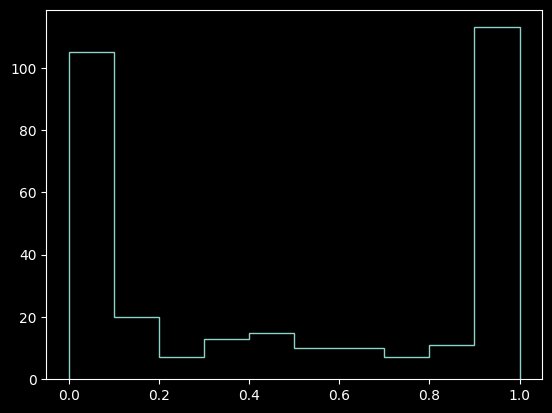

In [3]:
import numpy as np
import matplotlib.pyplot as plt

counts, bins = np.histogram(scores)
plt.stairs(counts, bins)
plt.show()

Remember that these samples have been collected in the wild, meaning that they could differ very much from the original distribution used during training (this model has been trained on data from 2017).
We will only use the ones with high-probability (> 95%).

# Evaluating the robustness against attacks

Machne learning is cool, but is it secure to deploy?
Let's try with an attack that manipulates the unused DOS metadata!

In [4]:
from tqdm import tqdm
from random import randbytes
import copy

example_sample = data_folder / "ClientUpdate.exe (x86).bin"
with open(example_sample, "rb") as f:
    x_sample = bytearray(f.read())


queries = 200

best_adv = None
best_score = np.inf

for q in (progress:=tqdm(range(queries))):
    x_adv = copy.deepcopy(x_sample)
    x_adv = x_adv[:2] + randbytes(58) + x_adv[60:]
    x_torch = torch.frombuffer(x_adv, dtype=torch.uint8).unsqueeze(0)
    adv_score = torch.sigmoid(model(x_torch.long())).item()
    if adv_score < best_score:
        best_adv = x_adv
        best_score = adv_score
    progress.set_description(f"Best score: {best_score*100:.3f} %")
    if adv_score < 0.5:
        print("Random attack successful!")
        break



Best score: 91.981 %: 100%|██████████| 200/200 [00:04<00:00, 47.66it/s]


Not so effective, isn't?
Even when you try multiple time: it seems that random modifications of DOS header are not enough for this sample.
Let's try another approach: we try with only *readable strings*.
This is to give a shot to the Cylance write-up: https://skylightcyber.com/2019/07/18/cylance-i-kill-you/


In [5]:
with open(data_folder / ".." / "goodware_strings.txt", "r") as f:
    all_goodware_strings = f.readlines()


In [6]:
import random

queries = 200

best_adv = None
best_score = np.inf

all_extracted = ''.join(all_goodware_strings)[:2**20]
payload = ''
for q in (progress:=tqdm(range(queries))):
    random_string = ''.join(random.choices(list(all_goodware_strings), k=200))
    random_string = bytearray(random_string, 'utf-8')
    payload += all_extracted
    x_adv = copy.deepcopy(x_sample)
    x_adv = x_adv + random_string
    x_torch = torch.frombuffer(x_adv, dtype=torch.uint8).unsqueeze(0)
    adv_score = torch.sigmoid(model(x_torch.long())).item()
    if adv_score < best_score:
        best_adv = x_adv
        best_score = adv_score
    progress.set_description(f"Best score: {best_score*100:.3f} %")
    if adv_score < 0.5:
        print("Random attack successful!")
        break

Best score: 78.369 %: 100%|██████████| 200/200 [00:09<00:00, 20.28it/s]


If you execute this strategy multiple times, *sometimes* you are able to drop the computed probability below zero!
But again, it is a random approach: you can try to customize it in order to keep relevant strings inside the payload, or merge the two approaches!

In [7]:


for q in (progress:=tqdm(range(queries))):
    x_adv = copy.deepcopy(x_sample)

    # HERE MODIFY x_adv as you please!

    x_torch = torch.frombuffer(x_adv, dtype=torch.uint8).unsqueeze(0)
    adv_score = torch.sigmoid(model(x_torch.long())).item()
    if adv_score < best_score:
        best_adv = x_adv
        best_score = adv_score
    progress.set_description(f"Best score: {best_score*100:.3f} %")
    if adv_score < 0.5:
        print("Custom attack successful!")
        break

Best score: 78.369 %: 100%|██████████| 200/200 [00:03<00:00, 50.54it/s]


# Automating attacks with maltorch

The library you have imported to create MalConv does not only provide models, but also attacks!
For instance, we now compute a guided attack that changes meaningful bytes using the parameters of the target themselves.
Since maltorch fully use PyTorch behind the curtain, we need to create DataLoaders to pass to the created attack:

In [8]:
from maltorch.adv.evasion.partialdos import PartialDOS
from maltorch.data.loader import  create_labels
from torch.utils.data import DataLoader, TensorDataset

x = torch.frombuffer(x_sample, dtype=torch.uint8).unsqueeze(0).long()
dataset = TensorDataset(x, create_labels(x, 1))
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

print(f"Original probability: {torch.sigmoid(model(x)).item():.2f}")

query_budget = 10
attack = PartialDOS(query_budget=query_budget)
results = attack(model, dataloader)
for advx,_ in results:
    print(f"Adv. probability: {torch.sigmoid(model(advx)).item():.2f}")

Original probability: 0.95


/Users/zangobot/Documents/Repositories/con-environment/.venv/lib/python3.12/site-packages/maltorch/adv/evasion/gradient_attack.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.sum().backward()


Adv. probability: 0.08


What the...? By just carefully-manipulating (not in a random way) the header DOS, this sample is now seen as benign by the network!
You can now test on all the samples in the folder that were considered very malicious:

In [9]:
from maltorch.data.loader import load_from_folder
from secmlt.metrics.classification import Accuracy

def load_high_malicious_samples_from_folder(model, folder, threshold=0.95):
    X = load_from_folder(folder)
    malicious = torch.sigmoid(model(X)) > threshold
    X = X[malicious.flatten(),...]
    return X

evil_X = load_high_malicious_samples_from_folder(model, data_folder, threshold=0.95)
evil_dataset = TensorDataset(evil_X, create_labels(evil_X, 1))
evil_dataloader = DataLoader(evil_dataset, batch_size=16, shuffle=False)

query_budget = 10
attack = PartialDOS(query_budget=query_budget)
adv_results = attack(model, evil_dataloader)

accuracy_pre_attack = Accuracy()(model, evil_dataloader)
accuracy_post_attack = Accuracy()(model, adv_results)
print(f"Accuracy pre-attack: {accuracy_pre_attack:.2f}")
print(f"Accuracy post-attack: {accuracy_post_attack:.2f}")


Accuracy pre-attack: 1.00
Accuracy post-attack: 0.51


Interesting! With only a 58-byte manipulation, this attack was able to reduce the probability of roughly half of the samples below the detection threshold (which is 0.5 for this model).

Could be better, right? Fear no more: maltorch is full of attacks and networks that you can test on your own!